In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 15.3MB/s]


In [3]:
df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [4]:
df['model'] = df.groupby('model')['selling_price'].transform('mean')
df['make'] = df.groupby('make')['selling_price'].transform('mean')

In [5]:
# Statmodels implementation of Linear regression
# Statmodels implementation of Linear regression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df[df.columns.drop('selling_price')]
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)

X_sm = sm.add_constant(X_tr_scaled)  #Statmodels default is without intercept, to add intercept we need to add constant

sm_model = sm.OLS(y_train, X_sm).fit()

print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Wed, 25 Sep 2024   Prob (F-statistic):               0.00
Time:                        16:50:40   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.5834      0.009    729.235      0.0

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
vif = pd.DataFrame()
X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)
vif['Features'] = X_t.columns


In [14]:
X_t.shape

(15856, 17)

In [13]:
for i in range(X_t.shape[1])

,Features
0,year
1,km_driven
2,mileage
3,engine
4,max_power
5,age
6,make
7,model
8,Individual
9,Trustmark Dealer


In [16]:
variance_inflation_factor(X_t.values, 1)

1.2102900727746801

In [17]:
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)

In [18]:
vif

/usr/local/lib/python3.10/dist-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Features,VIF
0,year,inf
5,age,inf
13,Petrol,18.29
10,Diesel,17.29
16,>5,13.04
15,5,11.75
3,engine,6.30
7,model,6.16
4,max_power,5.02
6,make,3.33


In [ ]:
#Removing the variable with highest VIF]
cols2 = vif["Features"][1:].values

In [ ]:
cols2

array(['age', 'Petrol', 'Diesel', '>5', '5', 'engine', 'model',
       'max_power', 'make', 'mileage', 'Manual', 'LPG', 'Electric',
       'km_driven', 'Individual', 'Trustmark Dealer'], dtype=object)

In [ ]:
X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]
X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
sm_model = sm.OLS(list(y_train), X2_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Tue, 30 Jan 2024   Prob (F-statistic):               0.00
Time:                        16:38:45   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.5834      0.009  

In [ ]:
vif = pd.DataFrame()
X_t = pd.DataFrame(X2, columns=X2.columns)
vif['Features'] = X2.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)

In [ ]:
vif

,Features,VIF
1,Petrol,18.29
2,Diesel,17.29
3,>5,13.04
4,5,11.75
5,engine,6.30
6,model,6.16
7,max_power,5.02
8,make,3.33
9,mileage,3.24
0,age,1.92


In [ ]:
vif_thr = 5
r2_thr = 0.85
i = 1
feats_removed = ['year']
while True:
  vif = pd.DataFrame()
  X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]
  vif['Features'] = cols2
  vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
  vif['VIF'] = round(vif['VIF'], 2)
  vif = vif.sort_values(by = "VIF", ascending = False)

  cols2 = vif["Features"][1:].values
  X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]

  X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
  sm_model = sm.OLS(list(y_train), X2_sm).fit()
  if (vif.iloc[0]['VIF'] < vif_thr) or (sm_model.rsquared_adj < r2_thr):
    print('Reached threshold')
    print('Highest vif:',vif.iloc[0])
    print('Current adj.R2',sm_model.rsquared_adj)
    print('Features removed:', i)
    print('List of features removed:', feats_removed)
    break
  feats_removed.append(vif.iloc[0]['Features'])
  i += 1

Reached threshold
Highest vif: Features    model
VIF          6.14
Name: 2, dtype: object
Current adj.R2 0.8322522946246915
Features removed: 3
List of features removed: ['year', 'Petrol', '>5']


In [ ]:
print(vif)
print(sm_model.summary())

            Features   VIF
2              model  6.14
1             engine  6.12
3          max_power  4.85
4               make  3.29
5            mileage  2.86
6             Diesel  2.14
7                age  1.87
8             Manual  1.78
0                  5  1.70
9           Electric  1.22
10         km_driven  1.21
11        Individual  1.09
12  Trustmark Dealer  1.02
13               LPG  1.01
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     6052.
Date:                Tue, 30 Jan 2024   Prob (F-statistic):               0.00
Time:                        16:52:13   Log-Likelihood:                -33356.
No. Observations:               15856   AIC:                         6.674e+04
Df Residuals:                   15842   BI

In [ ]:
X_sm = sm.add_constant(X_tr_scaled)
sm_model = sm.OLS(y_train, X_sm).fit()

In [ ]:
Y_hat = sm_model.predict(X_sm)
errors = Y_hat - y_train
           #A -  P

Text(0.5, 1.0, 'Histogram of residuals')

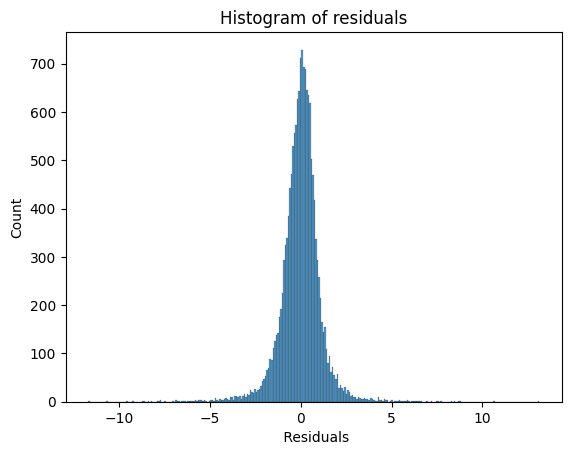

In [ ]:
import seaborn as sns

sns.histplot(errors)
plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

In [ ]:
from scipy import stats
res = stats.shapiro(errors)
res.statistic

/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


0.8901704549789429

In [ ]:
# H0 - Normal
# H1- not Normal
# p<0.05 -  reject null

In [ ]:
p>0.05 - Closer the value to 1, more is the normality.

In [ ]:
errors

3443    -0.193651
16090    0.124025
11070    0.404339
19214   -0.389842
17843   -0.006050
           ...   
1099    -1.362943
18898   -0.487388
11798    0.450178
6637    -1.146986
2575     1.361600
Name: selling_price, Length: 15856, dtype: float64

Text(0.5, 1.0, 'Predicted values vs Residuals')

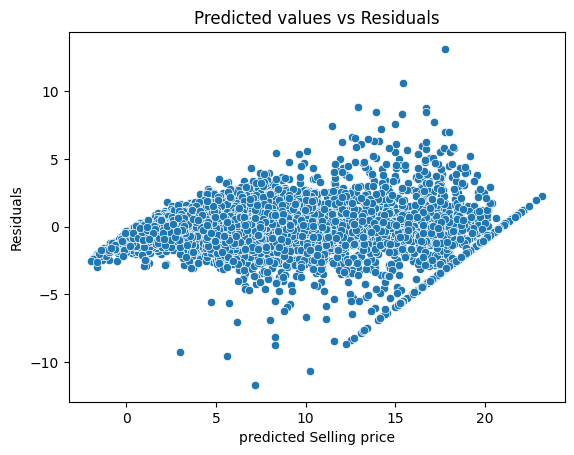

In [ ]:
sns.scatterplot(x=Y_hat,y=errors)
plt.xlabel("predicted Selling price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")

In [ ]:
#Goldfeld Quandt Test
# Performing the Goldfeld-Quandt test to check for Homoscedasticity -
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(y_train, X2_sm)
lzip(name, test)

[('F statistic', 1.0176613865185002), ('p-value', 0.21807877686817925)]

In [ ]:
H0 - homo
H1 - hetro
p<0.05
p>0.05

In [ ]:
Therefore, we accept the null hypothesis of homoscedasticity, and conclude that there is no strong evidence of heteroscedasticity in the data.

In [ ]:
A clothing store wants to predict sales based on factors like price, promotions, and store location.
Which assumption of linear regression is important for accurate sales predictions?
4 options
Active Duration(Most preferred: 30 seconds)
Appears for
45 Secs
A
Linearity between the independent variables and sales.
B
Normal distribution of sales.
C
MultiCollinearity among features
D
All of them